Определение корректора через яндекс спеллер

In [4]:
import requests
from typing import Any, Optional

from manuscript.data import Page


class YandexSpellerCorrector:
    SPELLER_URL = "https://speller.yandex.net/services/spellservice.json/checkText"

    def __init__(self, lang: str = "ru", timeout: float = 2.0):
        self.lang = lang
        self.timeout = timeout

    def predict(self, page: Page, image: Optional[Any] = None) -> Page:
        result = page.model_copy(deep=True)

        for block in result.blocks:
            for line in block.lines:
                for span in line.text_spans:
                    if not span.text:
                        continue
                    span.text = self._correct_text(span.text)

        return result

    def _correct_text(self, text: str) -> str:
        try:
            response = requests.get(
                self.SPELLER_URL,
                params={
                    "text": text,
                    "lang": self.lang,
                },
                timeout=self.timeout,
            )
            response.raise_for_status()
            fixes = response.json()

            if not fixes:
                return text

            corrected = text
            for fix in reversed(fixes):
                suggestions = fix.get("s") or []
                if not suggestions:
                    continue

                start = fix["pos"]
                end = start + fix["len"]
                corrected = corrected[:start] + suggestions[0] + corrected[end:]

            return corrected

        except Exception:
            return text


[YOLO] Device configuration:
  Requested device: cuda
  Requested providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']
  Active providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']
  Running on: CUDAExecutionProvider
[TRBA] Device configuration:
  Requested device: cuda
  Requested providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']
  Active providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']
  Running on: CUDAExecutionProvider
{'page': Page(blocks=[Block(lines=[Line(text_spans=[TextSpan(polygon=[(308.61279296875, 473.9430236816406), (404.61474609375, 473.9430236816406), (404.61474609375, 540.6297607421875), (308.61279296875, 540.6297607421875)], detection_confidence=0.919921875, text='з.)', recognition_confidence=0.8397642970085144, order=0)], order=0)], text_spans=[], order=0), Block(lines=[Line(text_spans=[TextSpan(polygon=[(442.0231018066406, 437.93780517578125), (939.6907958984375, 437.93780517578125), (939.6907958984375, 545.0529174804688), (442.

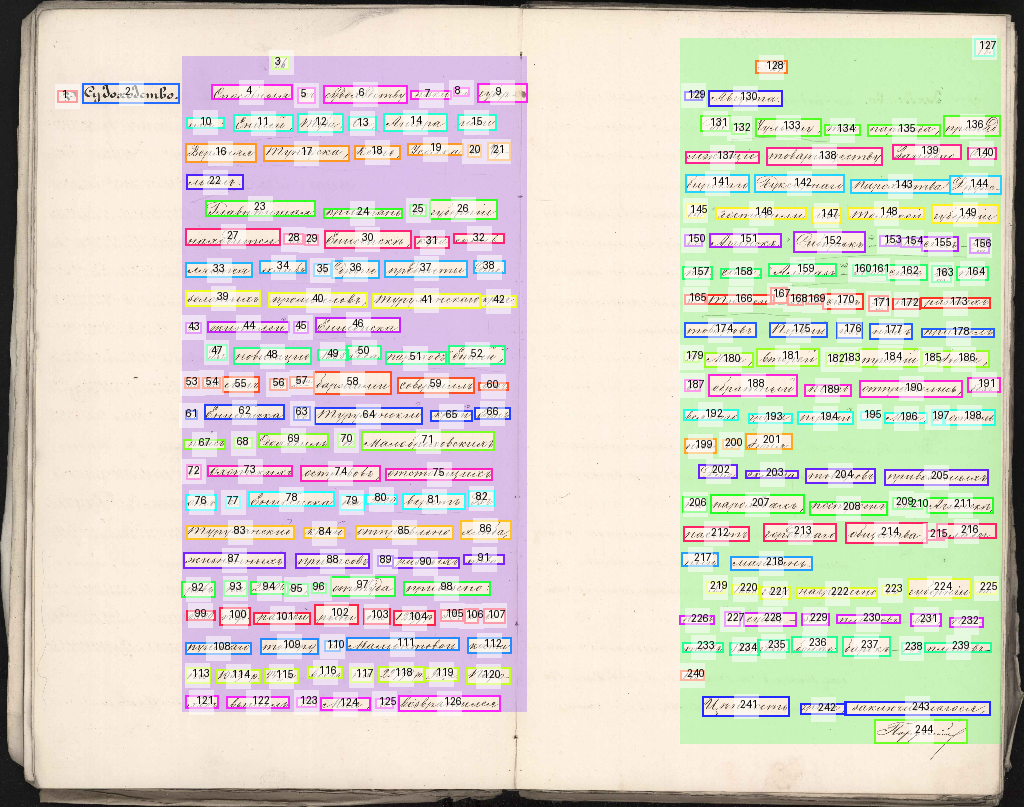

In [6]:
from manuscript import Pipeline
from manuscript.utils.visualization import visualize_page


image_path = r"C:\Users\USER\manuscript-ocr-2\example\ocr_example_image.jpg"

pipeline = Pipeline(
    corrector=YandexSpellerCorrector(), 
)

result = pipeline.predict(image_path)

print(result)

text = pipeline.get_text(result["page"])
print(text)

visualize_page(
    image_path,
    result["page"],
    show_lines=False,
    show_numbers=True,
    max_size = 1024
)